In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import label_binarize

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Load data
X = np.load("/content/drive/MyDrive/X_images.npy", mmap_mode='r')[:10000]
y = np.load('/content/drive/MyDrive/y_labels.npy')[:10000]
num_classes = len(np.unique(y))

In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, stratify=y, random_state=42
 )


In [12]:
# PyTorch Tensors: (N, C, H, W)
X_train = torch.tensor(X_train.transpose(0, 3, 1, 2), dtype=torch.float32)
X_test = torch.tensor(X_test.transpose(0, 3, 1, 2), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

In [14]:
# CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)

In [15]:
# Evaluate
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

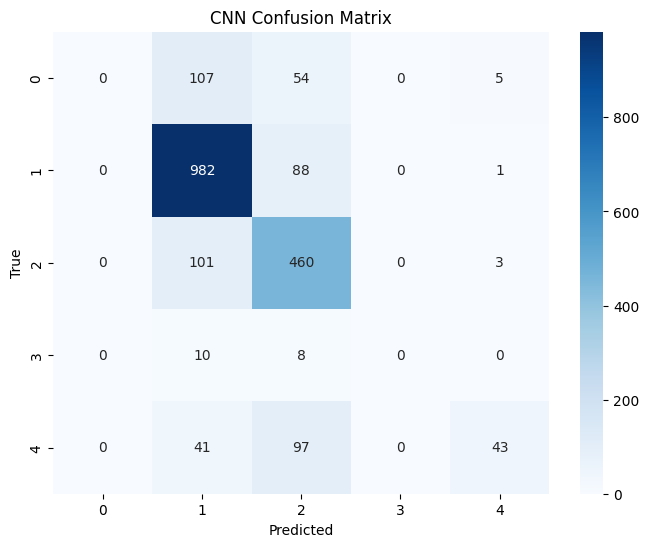

In [16]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [17]:
# AUC Score (Multiclass One-vs-Rest)
y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))
y_probs = np.array(all_probs)

auc_score = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
print(f"CNN Multiclass AUC Score: {auc_score:.4f}")

CNN Multiclass AUC Score: 0.8217


In [22]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, device='cpu'):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

    print("Finished Training")

In [33]:
# Evaluate the trained model
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
# Evaluate the trained model
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

auc_score = roc_auc_score(label_binarize(all_labels, classes=np.arange(num_classes)), np.array(all_probs), multi_class='ovr')
print(f"CNN Multiclass AUC Score: {auc_score:.4f}")

Confusion Matrix:
[[  0 107  54   0   5]
 [  0 982  88   0   1]
 [  0 101 460   0   3]
 [  0  10   8   0   0]
 [  0  41  97   0  43]]
CNN Multiclass AUC Score: 0.8217


In [37]:
#tuning different learning rates and batch sizes
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64, 128]
results = {}

device = "cuda" if torch.cuda.is_available() else "cpu"

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with Learning Rate: {lr}, Batch Size: {bs}")
        # Create new DataLoaders with the current batch size
        train_loader_tuned = DataLoader(TensorDataset(X_train, y_train), batch_size=bs, shuffle=True)
        test_loader_tuned = DataLoader(TensorDataset(X_test, y_test), batch_size=bs)

        model_tuned = CNNModel(num_classes)
        criterion = nn.CrossEntropyLoss()
        optimizer_tuned = optim.Adam(model_tuned.parameters(), lr=lr)

Training with Learning Rate: 0.01, Batch Size: 32
Training with Learning Rate: 0.01, Batch Size: 64
Training with Learning Rate: 0.01, Batch Size: 128
Training with Learning Rate: 0.001, Batch Size: 32
Training with Learning Rate: 0.001, Batch Size: 64
Training with Learning Rate: 0.001, Batch Size: 128
Training with Learning Rate: 0.0001, Batch Size: 32
Training with Learning Rate: 0.0001, Batch Size: 64
Training with Learning Rate: 0.0001, Batch Size: 128


In [42]:
 # The train_model function now returns cm and auc_score
cm_tuned, auc_score_tuned = train_model(model_tuned, train_loader_tuned, test_loader_tuned, criterion, optimizer_tuned, num_epochs=5, device=device)

results[(lr, bs)] = {'confusion_matrix': cm_tuned, 'auc_score': auc_score_tuned}
print(f"  AUC Score: {auc_score_tuned:.4f}")


Epoch 1/5, Loss: 0.6774
Epoch 2/5, Loss: 0.6580
Epoch 3/5, Loss: 0.6322
Epoch 4/5, Loss: 0.6159
Epoch 5/5, Loss: 0.5835
Finished Training
  AUC Score: 0.9093
